# Sanity check
## Minimal verification that cascade produces non-nonsense trajectories

In [ ]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.db import connect

from cascade.agents.db_orm import TrajectoryDB, DBTrajectoryFrame, DBTrainingFrame

In [2]:
db_url = 'postgresql://ase:pw@localhost:5432/cascade'
db = TrajectoryDB(db_url)
ase_db = connect(db_url)

In [3]:
runs = pd.DataFrame.from_records(db.list_runs())

In [4]:
runs.head()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
0,2026.07.22-04:10:06-74e61e,2026-07-21 23:10:06.556829-05:00,2026-07-21 23:23:44.543146-05:00,4,4
1,2026.07.21-22:29:11-74e61e,2026-07-21 17:29:11.556514-05:00,2026-07-21 17:29:11.851905-05:00,4,0
2,2026.07.21-20:10:17-6390d2,2026-07-21 15:10:18.406663-05:00,2026-07-21 16:11:32.486066-05:00,4,4
3,2026.07.21-19:18:40-aa3ed9,2026-07-21 14:18:40.685733-05:00,2026-07-21 14:20:25.824762-05:00,4,4
4,2026.07.21-18:22:32-aa3ed9,2026-07-21 13:22:33.780604-05:00,2026-07-21 13:24:22.266808-05:00,4,2


In [5]:
runs.tail()

,run_id,first_created,last_updated,n_trajectories,n_done_trajectories
448,2025.10.31-18:21:40-451a69,2025-10-31 13:21:40.509101-05:00,2025-10-31 13:21:40.519187-05:00,2,0
449,2025.10.31-18:18:57-451a69,2025-10-31 13:18:57.625552-05:00,2025-10-31 13:18:57.635521-05:00,2,0
450,2025.10.31-18:18:16-451a69,2025-10-31 13:18:16.936863-05:00,2025-10-31 13:18:16.947114-05:00,2,0
451,2025.10.31-18:17:34-451a69,2025-10-31 13:17:34.834340-05:00,2025-10-31 13:17:34.844208-05:00,2,0
452,2025.10.31-18:17:13-451a69,2025-10-31 13:17:13.515018-05:00,2025-10-31 13:17:13.521163-05:00,2,0


In [6]:
#last_run_id = good_run = '2026.02.26-18:47:48-cbece8'

In [7]:
last_run_id = runs['run_id'][0]
db.list_run_summary(last_run_id)

{'run_id': '2026.07.22-04:10:06-74e61e',
 'n_trajectories': 4,
 'n_done': 4,
 'n_active': 0,
 'total_chunks': 11,
 'total_passed_chunks': 8,
 'total_failed_chunks': 3,
 'total_pending_chunks': 0,
 'total_training_frames': 15,
 'first_created': datetime.datetime(2026, 7, 21, 23, 10, 6, 556829, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'last_updated': datetime.datetime(2026, 7, 21, 23, 23, 44, 543146, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400)))}

In [8]:
traj_info = pd.DataFrame.from_records(db.list_trajectories_in_run(last_run_id))
traj_info

,traj_id,target_length,chunks_completed,status,created_at,updated_at
0,0,10,2,TrajectoryStatus.COMPLETED,2026-07-21 23:10:06.556829-05:00,2026-07-21 23:23:42.891428-05:00
1,1,10,2,TrajectoryStatus.COMPLETED,2026-07-21 23:10:06.647571-05:00,2026-07-21 23:23:04.642347-05:00
2,2,10,2,TrajectoryStatus.COMPLETED,2026-07-21 23:10:06.742247-05:00,2026-07-21 23:15:21.711292-05:00
3,3,10,2,TrajectoryStatus.COMPLETED,2026-07-21 23:10:06.831452-05:00,2026-07-21 23:23:44.543146-05:00


In [9]:
run_summary = db.list_trajectory_summary(last_run_id, 0)
run_summary

{'run_id': '2026.07.22-04:10:06-74e61e',
 'traj_id': 0,
 'target_length': 10,
 'chunks_completed': 2,
 'created_at': datetime.datetime(2026, 7, 21, 23, 10, 6, 556829, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'updated_at': datetime.datetime(2026, 7, 21, 23, 23, 42, 891428, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=68400))),
 'n_chunk_attempts': 3,
 'n_unique_chunks': 2,
 'chunk_breakdown': {0: {'n_attempts': 2,
   'latest_status': 'PASSED',
   'latest_attempt_index': 1},
  1: {'n_attempts': 1, 'latest_status': 'PASSED', 'latest_attempt_index': 0}},
 'status_counts': {'PENDING': 0, 'PASSED': 2, 'FAILED': 1}}

In [10]:
chunks = pd.DataFrame.from_records(run_summary['chunk_breakdown'])
chunks

,0,1
n_attempts,2,1
latest_status,PASSED,PASSED
latest_attempt_index,1,0


In [11]:
traj_ids = traj_info['traj_id']

In [12]:
pd.set_option('display.max_rows', 100)

In [13]:
attempt_details = []
for traj_id in traj_ids:
    df = pd.DataFrame.from_records(db.list_trajectory_attempts(last_run_id, 0))
    df.insert(loc=0, column='traj_id', value=traj_id)
    attempt_details.append(df)
attempt_details = pd.concat(attempt_details)
attempt_details

,traj_id,chunk_id,attempt_index,n_frames,audit_status,model_version,created_at,updated_at
0,0,0,0,5,FAILED,0,2026-07-21 23:10:07.405531-05:00,2026-07-21 23:12:41.164642-05:00
1,0,0,1,5,PASSED,1,2026-07-21 23:21:21.032138-05:00,2026-07-21 23:23:02.695237-05:00
2,0,1,0,5,PASSED,1,2026-07-21 23:23:03.253702-05:00,2026-07-21 23:23:42.891428-05:00
0,1,0,0,5,FAILED,0,2026-07-21 23:10:07.405531-05:00,2026-07-21 23:12:41.164642-05:00
1,1,0,1,5,PASSED,1,2026-07-21 23:21:21.032138-05:00,2026-07-21 23:23:02.695237-05:00
2,1,1,0,5,PASSED,1,2026-07-21 23:23:03.253702-05:00,2026-07-21 23:23:42.891428-05:00
0,2,0,0,5,FAILED,0,2026-07-21 23:10:07.405531-05:00,2026-07-21 23:12:41.164642-05:00
1,2,0,1,5,PASSED,1,2026-07-21 23:21:21.032138-05:00,2026-07-21 23:23:02.695237-05:00
2,2,1,0,5,PASSED,1,2026-07-21 23:23:03.253702-05:00,2026-07-21 23:23:42.891428-05:00
0,3,0,0,5,FAILED,0,2026-07-21 23:10:07.405531-05:00,2026-07-21 23:12:41.164642-05:00


### These statuses are getting set at goofy times. the log says that these passed or failed, but theyre pending in the db...

In [14]:
passed_attempts = attempt_details.query('audit_status == "PASSED"')
passed_attempts.shape

(8, 8)

In [15]:
passed_attempts.groupby(['traj_id', 'chunk_id']).size().count()

8

In [ ]:
def get_frame_model_versions(db, run_id, traj_id):
    """Per-frame model_version, aligned with db.get_trajectory_atoms's frame ordering/dedup"""
    chunks = db.get_passed_chunks(run_id, traj_id)
    model_versions = []
    with db.session() as sess:
        for i, chunk in enumerate(chunks):
            frames = sess.query(DBTrajectoryFrame).filter_by(
                run_id=run_id,
                traj_id=traj_id,
                chunk_id=chunk['chunk_id'],
                attempt_index=chunk['attempt_index']
            ).order_by(DBTrajectoryFrame.frame_index).all()
            if i > 0:
                frames = frames[1:]
            model_versions.extend([chunk['model_version']] * len(frames))
    return np.array(model_versions)

In [ ]:
for traj_id in traj_ids: 
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    model_versions = get_frame_model_versions(db, last_run_id, traj_id)
    r0 = traj[0].get_positions()
    mad = np.zeros(len(traj))
    for i, a in enumerate(traj):
        mad[i] = np.mean(np.abs(a.get_positions() - r0))
    t = np.arange(mad.shape[0])
    plt.plot(t, mad, color='gray', alpha=0.3, zorder=1)
    for mv in np.unique(model_versions):
        mask = model_versions == mv
        plt.scatter(t[mask], mad[mask], label=f'model_version {mv}', zorder=2)
    plt.legend()
    plt.xlabel('timestep')
    plt.ylabel('$\mathbf{mean} [|\mathbf{r}_0 - \mathbf{r}_t|]$')
    plt.title(f'Traj {traj_id}')
    plt.show()

In [17]:
for traj_id in traj_ids: 
    traj = db.get_trajectory_atoms(last_run_id, traj_id)
    print(f'traj: {traj_id}, n_frames: {len(traj)}')

traj: 0, n_frames: 11
traj: 1, n_frames: 11
traj: 2, n_frames: 11
traj: 3, n_frames: 11


In [18]:
db.count_chunk_events_by_type(last_run_id)

{'STARTED_LABELING': 3,
 'STARTED_LABELING_FRAME': 15,
 'FINISHED_LABELING_FRAME': 15,
 'FINISHED_LABELING': 3}

## plot training results

In [19]:
training_logs = db.get_training_logs(last_run_id)

In [20]:
training_logs.head()

,training_round,member_index,epoch,energy_mae_train,force_rmse_train,stress_rmse_train,total_loss_train,energy_mae_valid,force_rmse_valid,stress_rmse_valid,total_loss_valid
0,0,0,0,0.007891,0.101364,0.001645,0.063687,0.017867,0.100692,0.001594,0.050981
1,0,0,1,0.023616,0.098482,0.001662,0.050497,0.017902,0.054397,0.001680,0.015097
2,0,0,2,0.014909,0.067430,0.001668,0.023292,0.010027,0.046857,0.001602,0.011156
3,0,0,3,0.008172,0.056008,0.001661,0.015922,0.007639,0.044739,0.001502,0.010150
4,0,0,4,0.009137,0.052600,0.001461,0.014022,0.011269,0.047985,0.001347,0.011667


In [21]:
df_long = (
    training_logs
    .melt(id_vars=["training_round", "member_index", "epoch"],
          var_name="metric",
          value_name="value")
)

df_long[["quantity", "split"]] = (
    df_long["metric"].str.rsplit("_", n=1, expand=True)
)

In [22]:
df_long

,training_round,member_index,epoch,metric,value,quantity,split
0,0,0,0,energy_mae_train,0.007891,energy_mae,train
1,0,0,1,energy_mae_train,0.023616,energy_mae,train
2,0,0,2,energy_mae_train,0.014909,energy_mae,train
3,0,0,3,energy_mae_train,0.008172,energy_mae,train
4,0,0,4,energy_mae_train,0.009137,energy_mae,train
...,...,...,...,...,...,...,...
155,0,1,5,total_loss_valid,0.010133,total_loss,valid
156,0,1,6,total_loss_valid,0.008084,total_loss,valid
157,0,1,7,total_loss_valid,0.004602,total_loss,valid
158,0,1,8,total_loss_valid,0.003911,total_loss,valid


In [23]:
df = training_logs.copy()

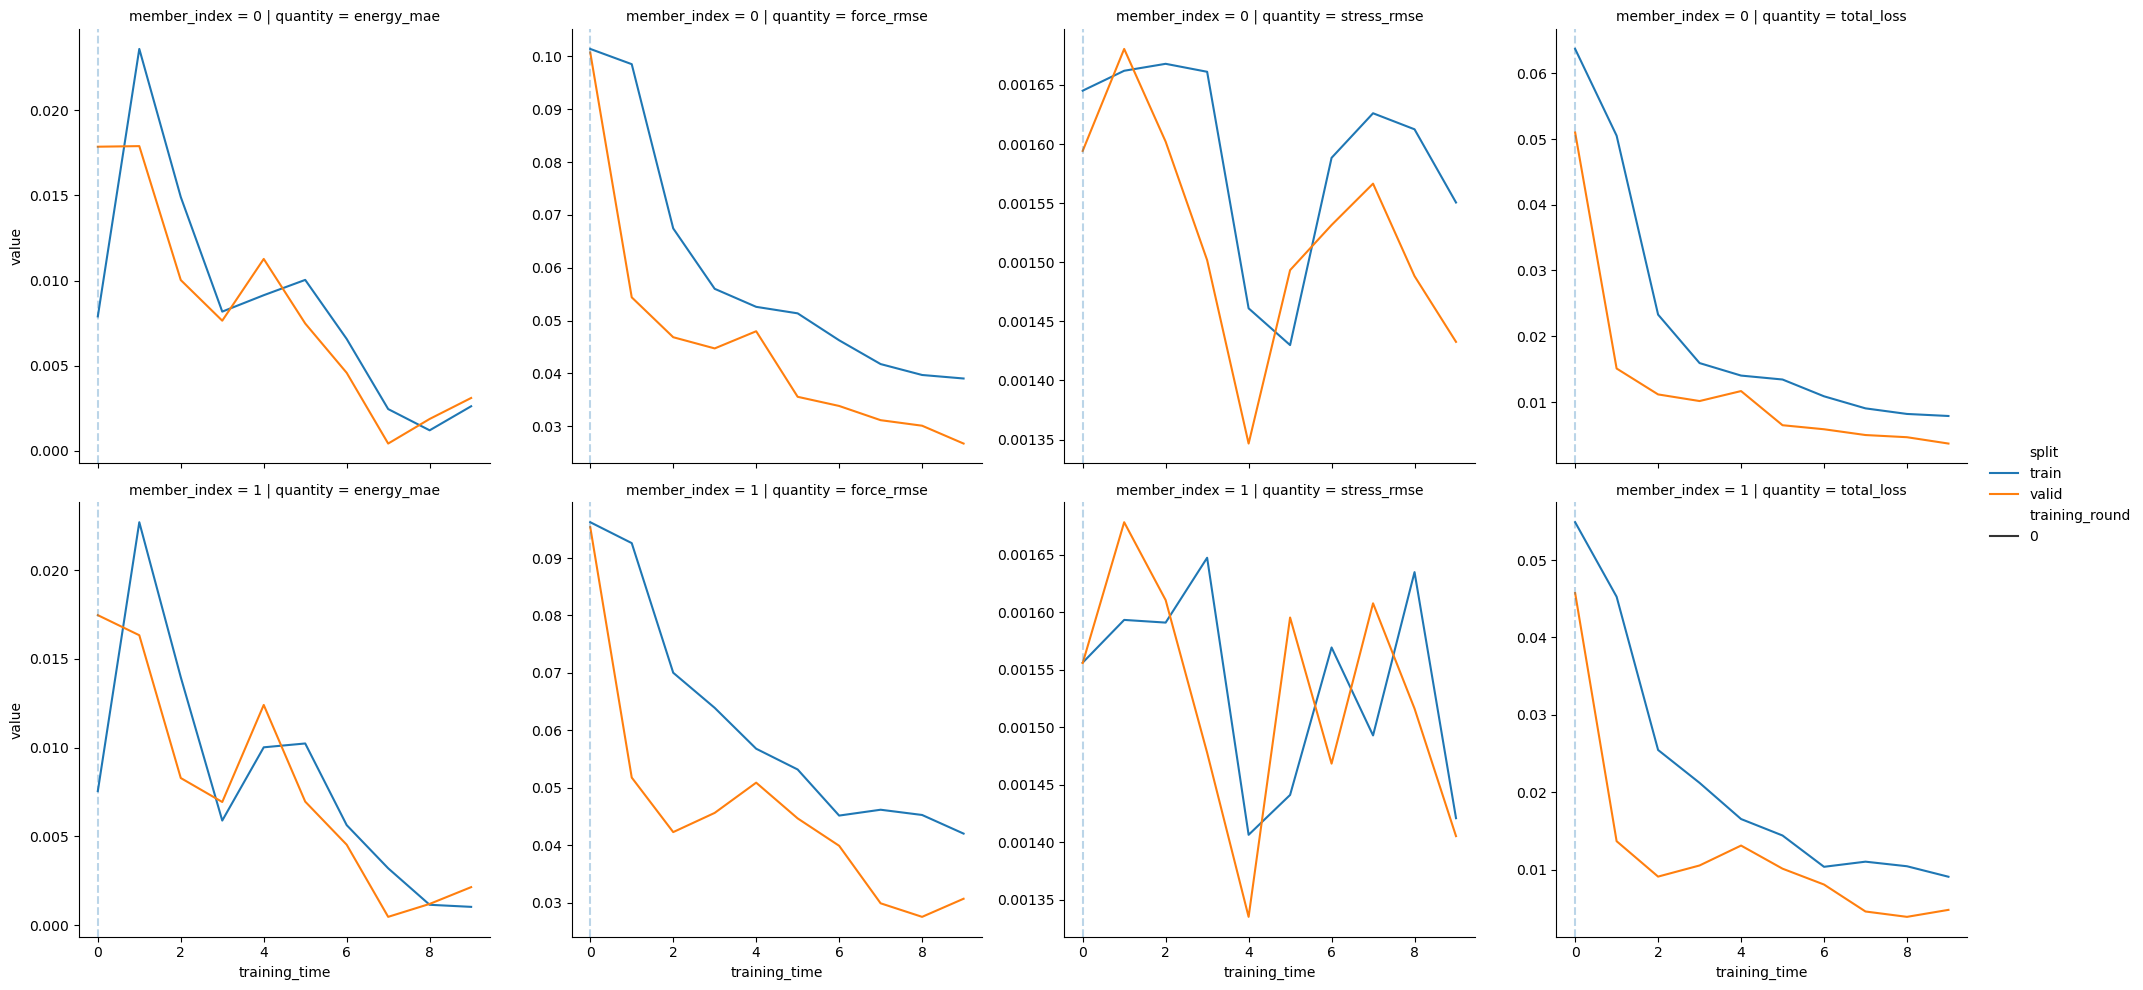

In [24]:
# --- sort ---
df = df.sort_values(["training_round", "member_index", "epoch"])

# --- build continuous training_time ---
round_max = df.groupby("training_round")["epoch"].max()
offsets = round_max.cumsum().shift(fill_value=0)

df["training_time"] = (
    df["epoch"] +
    df["training_round"].map(offsets)
)

# --- melt to long format ---
df_long = df.melt(
    id_vars=["training_round", "member_index", "epoch", "training_time"],
    var_name="metric",
    value_name="value"
)

# --- split metric into quantity + split ---
df_long[["quantity", "split"]] = (
    df_long["metric"].str.rsplit("_", n=1, expand=True)
)

# --- plot ---
g = sns.relplot(
    data=df_long,
    x="training_time",
    y="value",
    hue="split",                 # train vs valid
    style="training_round",      # distinguish rounds
    col="quantity",
    row="member_index",          # plot for each ensemble member
    kind="line",
    col_wrap=None,
    facet_kws={"sharey": False}
)

# --- add vertical round boundaries ---
for ax in g.axes.flatten():
    for boundary in offsets.values:
        ax.axvline(boundary, linestyle="--", alpha=0.3)

plt.show()

## look at UQ

In [26]:
# --- pull per-frame max UQ across the whole run ---
rows = []
for traj_id in traj_ids:
    for step, atoms in enumerate(db.get_trajectory_atoms(last_run_id, traj_id)):
        if 'uq_force_std_max' in atoms.info:
            rows.append({
                'traj_id': traj_id,
                'step': step,
                'uq_force_std_max': atoms.info['uq_force_std_max'],
            })
uq_df = pd.DataFrame(rows)
uq_df.head()

,traj_id,step,uq_force_std_max
0,0,0,0.025289
1,0,1,0.025372
2,0,2,0.025605
3,0,3,0.025928
4,0,4,0.026255


In [28]:
uq_df.shape

(44, 3)

In [31]:
# quantiles
print(uq_df['uq_force_std_max'].describe())

count    4.400000e+01
mean     1.590372e-02
std      1.276913e-02
min      6.664002e-08
25%      2.394850e-07
50%      2.541202e-02
75%      2.597025e-02
max      2.653485e-02
Name: uq_force_std_max, dtype: float64


In [32]:
# more quantiles
print(np.percentile(uq_df['uq_force_std_max'], [50, 90, 95, 99]))

[0.02541202 0.02638889 0.02648329 0.02653469]


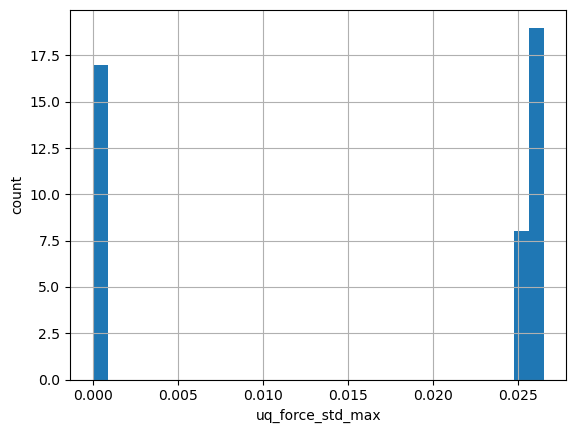

In [34]:
# histogram
uq_df['uq_force_std_max'].hist(bins=30)
plt.xlabel('uq_force_std_max')
plt.ylabel('count')
plt.show()

Its pretty bimodal

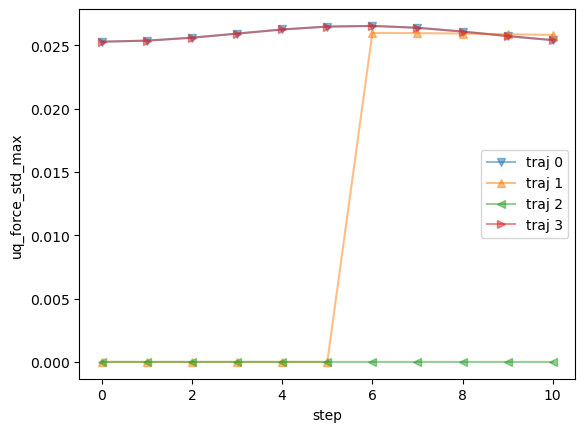

In [38]:
markers = 'v^<>'
for traj_id in traj_ids:
    sub = uq_df[uq_df['traj_id'] == traj_id]
    plt.plot(sub['step'], sub['uq_force_std_max'], marker=markers[traj_id], label=f'traj {traj_id}', alpha=0.5)
plt.xlabel('step')
plt.ylabel('uq_force_std_max')
plt.legend()
plt.show()

a little odd that athey are *so* close together, but these are really all the same system so maybe not so odd. its kindof cool how traj 1 steps like that.
I think we need a more interesting system before the UQ is helpful. Probably larger ensemble as well

## UQ vs error

In [ ]:
with db.session() as sess:
    calib_rows = sess.query(
        DBTrainingFrame.traj_id,
        DBTrainingFrame.chunk_id,
        DBTrainingFrame.model_version_sampled_from,
        DBTrainingFrame.calibration_uq,
        DBTrainingFrame.calibration_error,
    ).filter(
        DBTrainingFrame.run_id == last_run_id,
        DBTrainingFrame.calibration_error.isnot(None),
    ).all()

calib_df = pd.DataFrame(
    calib_rows,
    columns=['traj_id', 'chunk_id', 'model_version_sampled_from', 'calibration_uq', 'calibration_error']
)
calib_df.head()

In [ ]:
for mv in sorted(calib_df['model_version_sampled_from'].unique()):
    sub = calib_df[calib_df['model_version_sampled_from'] == mv]
    plt.scatter(sub['calibration_uq'], sub['calibration_error'], label=f'model_version {mv}', alpha=0.7)
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('UQ at sample time (calibration_uq)')
plt.ylabel('observed force error (calibration_error)')
plt.title('UQ vs. observed error')
plt.show()

## cell size: start vs end

In [ ]:
def get_first_and_last_atoms(db, run_id, traj_id):
    """First-ever frame, and last-ever recorded frame (from the last attempt that actually
    wrote frames, even if that chunk/attempt ultimately failed audit or never got audited)."""
    with db.session() as sess:
        first = sess.query(DBTrajectoryFrame).filter_by(run_id=run_id, traj_id=traj_id).order_by(
            DBTrajectoryFrame.chunk_id, DBTrajectoryFrame.attempt_index, DBTrajectoryFrame.frame_index
        ).first()
        last = sess.query(DBTrajectoryFrame).filter_by(run_id=run_id, traj_id=traj_id).order_by(
            DBTrajectoryFrame.chunk_id.desc(), DBTrajectoryFrame.attempt_index.desc(), DBTrajectoryFrame.frame_index.desc()
        ).first()
        first_atoms = db._deserialize_atoms(first.atoms_blob)
        last_atoms = db._deserialize_atoms(last.atoms_blob)
    return first_atoms, last_atoms

cell_rows = []
for traj_id in traj_ids:
    first_atoms, last_atoms = get_first_and_last_atoms(db, last_run_id, traj_id)
    cell_rows.append({
        'traj_id': traj_id,
        'start_volume': first_atoms.get_volume(),
        'end_volume': last_atoms.get_volume(),
    })
cell_df = pd.DataFrame(cell_rows)
cell_df

In [ ]:
x = np.arange(len(cell_df))
width = 0.35
plt.bar(x - width/2, cell_df['start_volume'], width, label='start')
plt.bar(x + width/2, cell_df['end_volume'], width, label='end')
plt.xticks(x, cell_df['traj_id'])
plt.xlabel('traj_id')
plt.ylabel('cell volume ($\mathrm{\AA}^3$)')
plt.legend()
plt.title('Cell volume: start vs. end')
plt.show()